Import Libraries

In [1]:
# Parallelization
import os # Operating system interface
import tempfile
import multiprocessing as mp # Package for supporting spawning processes using APi similar to threading module
from multiprocessing import Pool # Allows pooling resources into subprocesses for making effective use of multiple cpus
from multiprocessing import cpu_count # Counts the number of cpu's in current system
import concurrent.futures
from concurrent.futures import ProcessPoolExecutor # Class for parallelization that serves an updated version of pool

# MDAnalysis
import MDAnalysis as mda # Package for general simulation analysis
from MDAnalysis.analysis import rms # MDAnalysis function for analysis of root mean square quanities
from MDAnalysis.lib.distances import distance_array

# MDTraj 
import mdtraj as md # Python library for analyzing molecular dynamics trajectories

# Itertools
from itertools import product # Product function of python's itertools module that returns cartesian product of input iterables

# Hole2
from mdahole2.analysis import hole # Function for pore interior analysis
from mdahole2.analysis import HoleAnalysis

# Plotting
# Color blind friendly color palettes for plotting
# Sunset spectrum (blue to tan to ruby): #364B9A #4A7BB7 #6EA6CD #98CAE1 #C2E4EF #EAECCC #FEDA8B #FDB366 #F67E4B #DD3D2D #A50026
# Viridis spectrum (gold to seafoam to violet): #FDE725 #5EC962 #21918C #3B528B #440154
# Magma spectrum (yellow to magenta to black): #FCFDBF #FC8961 #B73779 #51127C #000004
# Monochromatic teal spectrum (teal to aqua to black): #FEFFFF #DEF2F1 #3AAFA9 #2B7A78 #17252A
import matplotlib.pyplot as plt # Comprehensive library for creating visualizations in Python

# NGLView
import nglview as nv # Package for interactive visualization of proteins and trajectories

# NumPY
import numpy as np # Fundamental package for mathematical operations and numerical computations in Python

# Warnings
import warnings # Python core function for handling built-in exceptions
warnings.filterwarnings('ignore') # Ignore unnessary warnings from MDAnalysis

Hole Class and Methods

In [2]:
class MDAHoleAnalysis:
    StructureFileTypes = {'.pdb'} # Available structure file types
    TrajectoryFileTypes = {'.dcd','.xtc'} # Available trajectory file types

    # Function for initiating protein universes
    def __init__(self,Structure,Trajectory=None,FrameStep=100):
        if all(isinstance(Struct,str) for Struct in Structure): # If structure input is a string, assigns to structure
            Structures = Structure
        elif not isinstance(Structure,list): # Otherwise outputs an error for wrong input type
            raise TypeError("Structure must either be a string or a list of strings.")
        if Trajectory is None: # No trajectory file required, instead makes a blank structure for universe creation
            Trajectories = [None] * len(Structure)
        elif all(isinstance(Traj,str) for Traj in Trajectory): # If trajectory exists and is a string/list of strings, creates trajectory object
            Trajectories = Trajectory
        elif not isinstance(Trajectory,list): # If provided and wrong file type, outputs error
            raise TypeError("Trajectory must be a string, a list of strings, or none.")
        if len(Structures) != len(Trajectories): # If there are not the same amount of structures and trajectories, produce error
            raise ValueError("The number of structures and trajectories must be the same.")
        for Struct in Structures: # Checks for every structure if in supported structure file types
            if os.path.splitext(Struct)[1].lower() not in self.StructureFileTypes:
                raise ValueError(f"File type {os.path.splitext(Struct)[1].lower()} is unsupported for structures.")
        for Traj in Trajectories: # Checks for every trajectory if in supported file types
            if Traj is not None:
                if os.path.splitext(Traj)[1].lower() not in self.TrajectoryFileTypes:
                    raise ValueError(f"File type {os.path.splitext(Traj)[1].lower()} is unsupported for trajectories.")
        # Creates universe from structures and optionally and trajectory
        self.StructureList = Structures
        self.TrajectoryList = Trajectories
        self.FrameStep = FrameStep # Saves frame step, i.e. with what frequency are frames read

    def PoreAnalysis(self,StartFrame=0,EndFrame=None):
        self.PoreProfile = []
        self.PoreDistanceList = []
        self.PoreRadiusList = [] 
        for Structure, Trajectory in zip(self.StructureList, self.TrajectoryList):
            if Trajectory is None:
                Profile = hole(Structure)
            else:
                Universe = mda.Universe(Structure,Trajectory)
                if EndFrame is None:
                    EndFrame = len(Universe.trajectory)
                with HoleAnalysis(Universe) as HoleProfile:
                    HoleProfile.run(start=StartFrame, stop=EndFrame, step=self.FrameStep)
                Profile = HoleProfile
            self.PoreProfile.append(Profile)
            if isinstance(Profile, dict):
                PoreDictionary = list(Profile.values())[0]  # take the first (or only) entry
                self.PoreDistanceList.append(PoreDictionary['rxn_coord'])
                self.PoreRadiusList.append(PoreDictionary['radius'])
            elif hasattr(Profile, '__iter__') and all(hasattr(p, '__getitem__') for p in Profile):
                self.PoreDistanceList.append(np.array([p[0] for p in Profile]))
                self.PoreRadiusList.append(np.array([p[1] for p in Profile]))
            else:
                self.PoreDistanceList.append(np.array([Profile]))
                self.PoreRadiusList.append(np.array([0.0]))

Hole Calculations and Plotting

'HA = MDAHoleAnalysis(Structures)\nHA.PoreAnalysis()\nPoreDistances = HA.PoreDistanceList\nPoreRadii = HA.PoreRadiusList\n\nf,PoreDimensionTemp = plt.subplots(figsize=(8,15))\nPoreDimensionTemp.plot(PoreRadii[0],PoreDistances[0],color=\'#FEDA8B\',label="280")\nPoreDimensionTemp.plot(PoreRadii[1],PoreDistances[1],color=\'#FDB366\',label="310")\nPoreDimensionTemp.plot(PoreRadii[2],PoreDistances[2],color=\'#F67E4B\',label="315")\nPoreDimensionTemp.plot(PoreRadii[3],PoreDistances[3],color=\'#DD3D2D\',label="325")\nPoreDimensionTemp.plot(PoreRadii[4],PoreDistances[4],color=\'#A50026\',label="340")\nPoreDimensionTemp.set_title("TRPV1 Pore Radii across Temperatures",fontsize=20)\nPoreDimensionTemp.set_xlabel("Protein Radii",fontsize=16)\nPoreDimensionTemp.set_ylabel("Pore Coordinate",fontsize=16)\nPoreDimensionTemp.set_xlim(0,10)\nPoreDimensionTemp.set_ylim(80,160)\nPoreDimensionTemp.legend(title=\'Temperature (K)\',loc="lower right",title_fontsize=16,fontsize=16)\nPoreDimensionTemp.tick_para

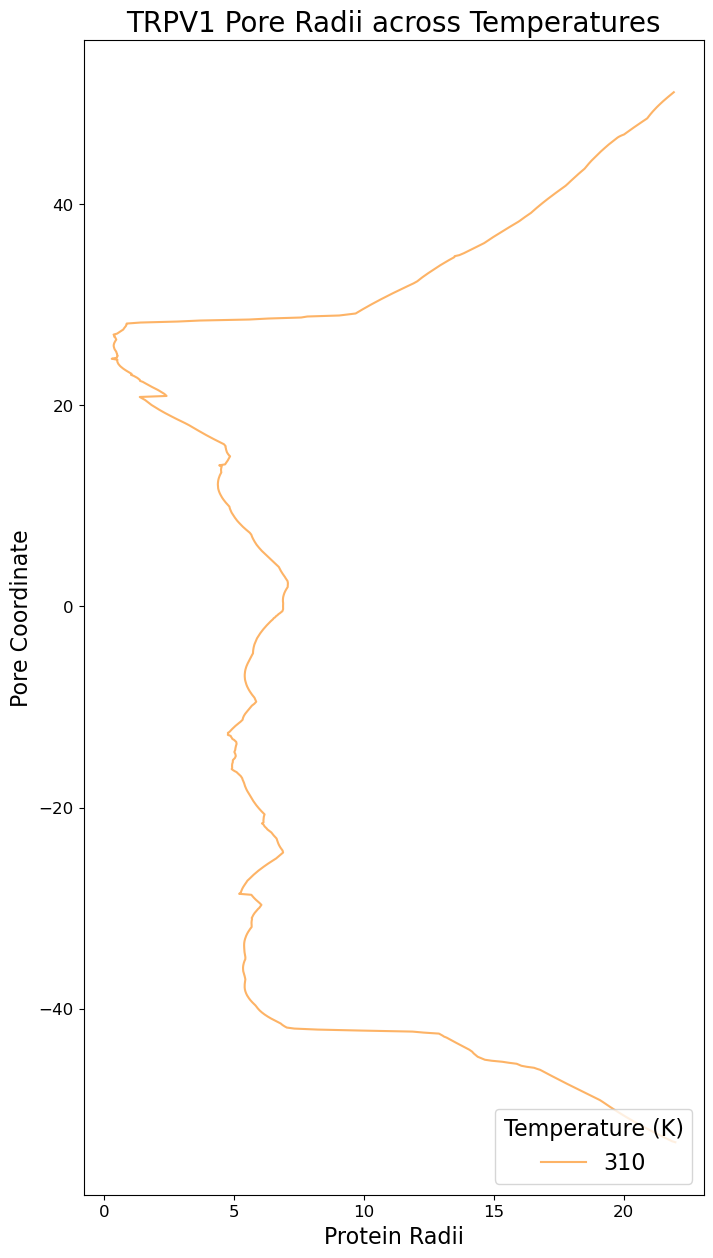

In [ ]:
Structures = ["/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/Atomistic/280K15/NPT-Protein-Center.pdb",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/Atomistic/310K15/NPT-Protein-Center.pdb",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/Atomistic/315K15/NPT-Protein-Center.pdb",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/Atomistic/325K15/NPT-Protein-Center.pdb",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/Atomistic/340K15/NPT-Protein-Center.pdb"]

HA = MDAHoleAnalysis(Structures)
HA.PoreAnalysis()
PoreDistances = HA.PoreDistanceList
PoreRadii = HA.PoreRadiusList

f,PoreDimensionTemp = plt.subplots(figsize=(8,15))
PoreDimensionTemp.plot(PoreRadii[0],PoreDistances[0],color='#FEDA8B',label="280")
PoreDimensionTemp.plot(PoreRadii[1],PoreDistances[1],color='#FDB366',label="310")
PoreDimensionTemp.plot(PoreRadii[2],PoreDistances[2],color='#F67E4B',label="315")
PoreDimensionTemp.plot(PoreRadii[3],PoreDistances[3],color='#DD3D2D',label="325")
PoreDimensionTemp.plot(PoreRadii[4],PoreDistances[4],color='#A50026',label="340")
PoreDimensionTemp.set_title("TRPV1 Pore Radii across Temperatures",fontsize=20)
PoreDimensionTemp.set_xlabel("Protein Radii",fontsize=16)
PoreDimensionTemp.set_ylabel("Pore Coordinate",fontsize=16)
PoreDimensionTemp.set_xlim(0,10)
PoreDimensionTemp.set_ylim(80,160)
PoreDimensionTemp.legend(title='Temperature (K)',loc="lower right",title_fontsize=16,fontsize=16)
PoreDimensionTemp.tick_params(axis='both', which='major', labelsize=12)
PoreDimensionTemp.tick_params(axis='both', which='minor', labelsize=12)